# Structural-Break Exploration

Identify candidate regime changes in monthly Stack Overflow question activity without fixing intervention dates in advance. Results are exploratory, not causal.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt

def root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        q = p / 'stack_exchange_analysis'
        if (p/'database').exists(): return p
        if (q/'database').exists(): return q
    raise FileNotFoundError('stack_exchange_analysis')

PROJECT_ROOT=root(); DATA_DIR=PROJECT_ROOT/'database'; ANALYSIS_DIR=PROJECT_ROOT/'analysis'; ANALYSIS_DIR.mkdir(exist_ok=True)
sys.path.insert(0,str(PROJECT_ROOT/'src'))
from analysis_utils import read_csv_flexible, drop_incomplete_last_period, save_figure

df=read_csv_flexible(DATA_DIR/'new-questions-per-day-by-sites-since-2008.csv')
df['Day']=pd.to_datetime(df['Day'],errors='coerce'); df['StackOverflowQuestions']=pd.to_numeric(df['StackOverflowQuestions'],errors='coerce')
monthly=df.dropna(subset=['Day','StackOverflowQuestions']).set_index('Day')['StackOverflowQuestions'].resample('MS').sum(min_count=1)
monthly=drop_incomplete_last_period(monthly,'M').dropna(); y=np.log1p(monthly.to_numpy(float)); x=np.arange(len(y),dtype=float)
print(monthly.index.min(), monthly.index.max(), len(monthly))

2008-07-01 00:00:00 2026-05-01 00:00:00 215


## Rolling slope

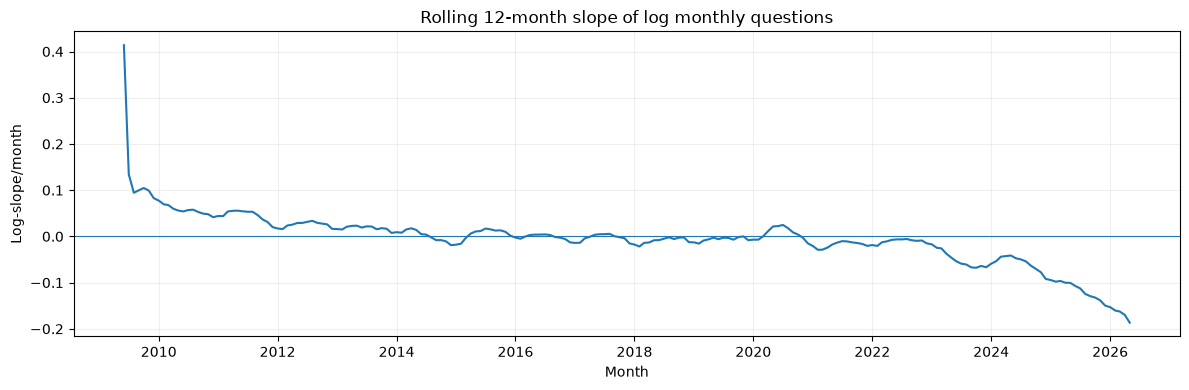

In [2]:
window=12; slopes=np.full(len(y),np.nan)
for end in range(window-1,len(y)):
    slopes[end]=np.polyfit(np.arange(window),y[end-window+1:end+1],1)[0]
rolling=pd.Series(slopes,index=monthly.index)
fig,ax=plt.subplots(figsize=(12,4)); ax.axhline(0,lw=.8); ax.plot(rolling); ax.set(title='Rolling 12-month slope of log monthly questions',xlabel='Month',ylabel='Log-slope/month'); ax.grid(alpha=.2); save_figure(fig,ANALYSIS_DIR/'questions_rolling_slope.png'); plt.show()

## Exhaustive segmented-trend scan

,candidate_month,sse_gain,segmented_sse
134,2021-03-01,198.075808,136.308241
135,2021-04-01,198.074130,136.309919
133,2021-02-01,198.056653,136.327396
136,2021-05-01,198.047590,136.336459
132,2021-01-01,198.025620,136.358429
137,2021-06-01,198.000883,136.383166
131,2020-12-01,197.979765,136.404283
138,2021-07-01,197.932961,136.451088
130,2020-11-01,197.926054,136.457994
129,2020-10-01,197.865523,136.518526


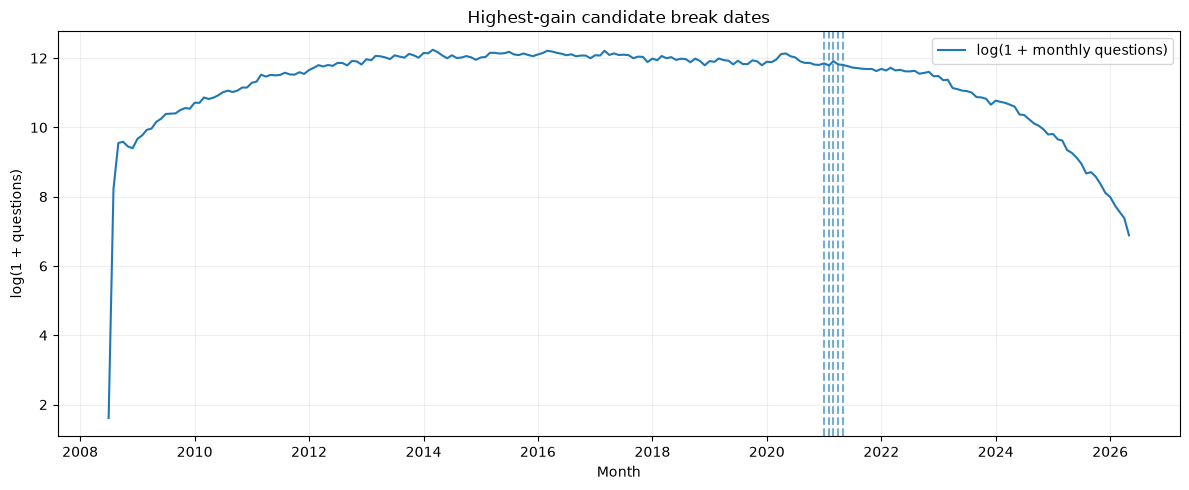

In [3]:
def sse(xx,yy):
    X=np.c_[np.ones(len(xx)),xx]; b=np.linalg.lstsq(X,yy,rcond=None)[0]; r=yy-X@b; return float(r@r)
base=sse(x,y); rows=[]; min_size=18
for split in range(min_size,len(y)-min_size):
    segmented=sse(x[:split],y[:split])+sse(x[split:],y[split:])
    rows.append((monthly.index[split],base-segmented,segmented))
scan=pd.DataFrame(rows,columns=['candidate_month','sse_gain','segmented_sse']).sort_values('sse_gain',ascending=False)
display(scan.head(15))
fig,ax=plt.subplots(figsize=(12,5)); ax.plot(monthly.index,np.log1p(monthly),label='log(1 + monthly questions)')
for dt in scan.head(5)['candidate_month'].sort_values(): ax.axvline(dt,ls='--',alpha=.6)
ax.set(title='Highest-gain candidate break dates',xlabel='Month',ylabel='log(1 + questions)'); ax.grid(alpha=.2); ax.legend(); save_figure(fig,ANALYSIS_DIR/'questions_candidate_breaks.png'); plt.show()

## Takeaways
Candidate dates must be checked for robustness to aggregation frequency, transformation, seasonality, deletion/survival bias, and incomplete final periods before interpretation.